In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

n_samples = 60 * 24
mu = [20, 0]
sigma = [0.1, 1]
data = np.random.normal(loc=mu, scale=sigma, size=(n_samples,2))
# 温度センサ異常を模擬（平均値を100℃上げる）
idx0 = math.floor(n_samples * 12/24)
idx1 = math.floor(n_samples * 13/24)
data[idx0:idx1,0] = data[idx0:idx1,0] + 100
data = {"temperature": data[:,0], "vibration": data[:,1]}

delta = timedelta(hours=24)
sampling_period = timedelta(minutes=1)
n_samples = math.floor(delta / sampling_period)
t0 = datetime(2026, 3, 18, 0, 0, 0)
time = [t0 + timedelta(minutes=i) for i in range(n_samples)]

df = pd.DataFrame(data, time)
df

,temperature,vibration
2026-03-18 00:00:00,20.030245,0.480705
2026-03-18 00:01:00,20.129854,0.082938
2026-03-18 00:02:00,19.871633,-0.324130
2026-03-18 00:03:00,20.018824,-0.418169
2026-03-18 00:04:00,20.104168,1.007524
...,...,...
2026-03-18 23:55:00,19.884035,-0.211321
2026-03-18 23:56:00,19.817528,-0.153514
2026-03-18 23:57:00,20.102178,1.174890
2026-03-18 23:58:00,20.045954,-0.616593


<Axes: >

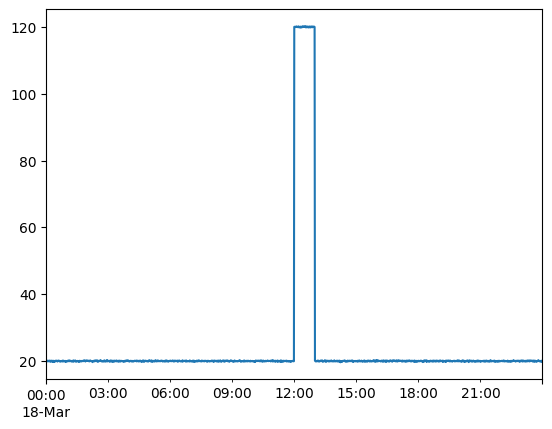

In [2]:
df["temperature"].plot()

<Axes: >

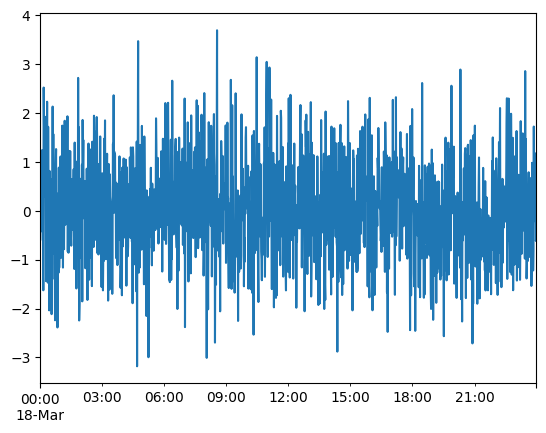

In [3]:
df["vibration"].plot()

In [4]:
hourly_features = df.resample("60min").agg(
    {"temperature": "mean", "vibration": "std"}
)
hourly_features

,temperature,vibration
2026-03-18 00:00:00,19.979597,1.198183
2026-03-18 01:00:00,20.006218,0.972446
2026-03-18 02:00:00,20.018900,0.960359
2026-03-18 03:00:00,19.996976,0.963427
2026-03-18 04:00:00,20.003733,1.067245
2026-03-18 05:00:00,20.007471,0.843258
2026-03-18 06:00:00,20.009632,1.017600
2026-03-18 07:00:00,19.993213,0.996164
2026-03-18 08:00:00,20.016121,1.142497
2026-03-18 09:00:00,19.992090,1.070601


In [5]:
score_on_temp = (hourly_features["temperature"] - 20) ** 2
score_on_vib = (hourly_features["vibration"] - 1) ** 2
anomaly_score = pd.concat([score_on_temp, score_on_vib], axis=1).mean(axis=1).tolist()
anomaly_score

[0.019846486230985873,
 0.000398957643457929,
 0.0009643035124795692,
 0.0006733787148639146,
 0.002267926953324234,
 0.012311905494104398,
 0.0002012691781967894,
 3.0387603262624295e-05,
 0.010282707737441957,
 0.002523531318707965,
 0.012465487872346259,
 0.005926294856354338,
 4999.396767172501,
 0.0004368972080694804,
 0.0030567720471499746,
 3.817461578957551e-05,
 0.0008652305193411905,
 0.00148650292072579,
 0.0007047102472646376,
 0.00012300769519615234,
 0.004876279993713456,
 0.025350974347895096,
 0.00017335199492118765,
 0.002358795422665762]

<Axes: >

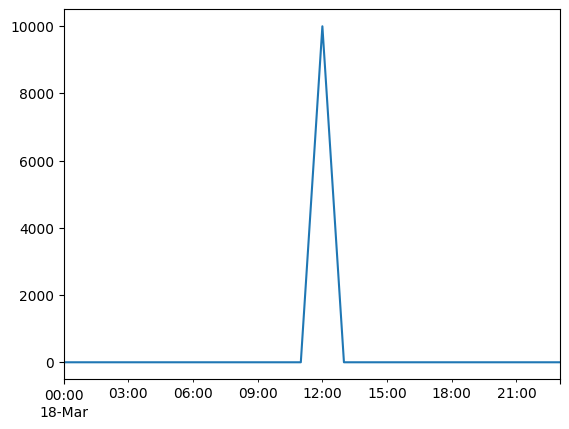

In [6]:
score_on_temp.plot()

<Axes: >

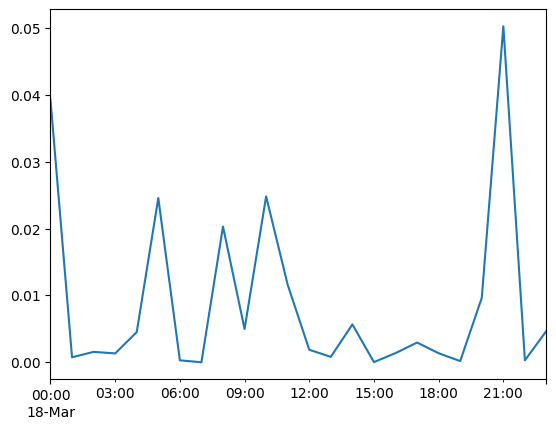

In [7]:
score_on_vib.plot()

In [12]:
hourly_features = (
    df.resample("60min")
    .agg({"temperature": "max", "vibration": "std"})
    .rename(
        columns={"temperature": "temperature_max", "vibration": "vibration_std"}
    )
)
hourly_features.to_dict(orient="list")

{'temperature_max': [20.1646127094708,
  20.211151157405595,
  20.28681006203773,
  20.207317508298676,
  20.19753825896292,
  20.223157659832356,
  20.198752740693674,
  20.17751077681094,
  20.212773479101102,
  20.2524330078288,
  20.248878690373573,
  20.17331112946529,
  120.18007810013748,
  20.262989648626842,
  20.180321863483424,
  20.3143316873393,
  20.231973553335763,
  20.23684524811598,
  20.22007793950159,
  20.227477938417984,
  20.21176602330819,
  20.208436242864792,
  20.2660109290886,
  20.250065041141763],
 'vibration_std': [1.1981834689123205,
  0.9724455053554877,
  0.9603591305093203,
  0.9634266091939154,
  1.0672452361387899,
  0.8432581791809389,
  1.0176003424211162,
  0.9961638797882398,
  1.1424974847179734,
  1.0706009467785174,
  1.1575077859188418,
  1.1076772368768733,
  1.0434827061627998,
  0.9713016585298749,
  1.0753313544083904,
  1.0063687961778642,
  0.9627986565560089,
  0.945551789803877,
  0.9630241780984535,
  0.9861680510951819,
  1.0981853